In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df_list = pd.read_csv("listing_residential.csv")

print(df_list.shape)
df_list.head()

C:\Users\junki\AppData\Local\Temp\ipykernel_6720\1573011601.py:1: DtypeWarning: Columns (0: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = pd.read_csv("listing_residential.csv")


(571232, 55)


,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,MiddleOrJuniorSchoolDistrict
0,1340000.0,1074973329,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,Residential,...,NaN,False,1.0,NaN,One,False,NaN,NaN,90067,NaN
1,2500000.0,1074954552,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,Residential,...,NaN,True,2.0,NaN,Two,False,3.0,Capistrano Unified,92677,NaN
2,3150000.0,1074936537,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,Residential,...,NaN,True,2.0,NaN,Two,NaN,2.0,NaN,91108,NaN
3,3090000.0,1074917818,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,Residential,...,Chaparral,True,NaN,Diamond Bar,ThreeOrMore,False,4.0,Walnut Valley Unified,91765,NaN
4,12725000.0,1074143166,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,Residential,...,Corona Del Mar,True,NaN,Corona Del Mar,ThreeOrMore,False,2.0,Newport Mesa Unified,92662,NaN


In [4]:
# check all features for percentage of missing values
missing_ratio = df_list.isna().sum() / df_list.shape[0]
print(missing_ratio.sort_values(ascending=False))

# call features that contain more than 90% of missing values
missing_high = missing_ratio[missing_ratio>=0.9]
print()
print("Missing more than 90%")
print(missing_high.sort_values(ascending=False))

TaxAnnualAmount                 1.000000
FireplacesTotal                 1.000000
TaxYear                         1.000000
ElementarySchoolDistrict        1.000000
BusinessType                    1.000000
MiddleOrJuniorSchoolDistrict    1.000000
BuilderName                     0.953802
ElementarySchool                0.880282
MiddleOrJuniorSchool            0.880240
BuyerAgencyCompensation         0.861715
BuyerAgencyCompensationType     0.861680
HighSchool                      0.842964
ClosePrice                      0.751386
BuyerOfficeName                 0.728989
BuyerAgentFirstName             0.726386
BuyerAgentLastName              0.725126
CloseDate                       0.712521
SubdivisionName                 0.632410
PurchaseContractDate            0.523287
HighSchoolDistrict              0.300438
Stories                         0.176132
AttachedGarageYN                0.174642
Latitude                        0.140965
Longitude                       0.140965
MLSAreaMajor    

In [5]:
df_list = df_list.drop(columns = missing_high.index)

(df_list.isna().sum() / df_list.shape[0]) >= 0.9

OriginalListPrice              False
ListingKey                     False
CloseDate                      False
ClosePrice                     False
ListAgentFirstName             False
ListAgentLastName              False
Latitude                       False
Longitude                      False
UnparsedAddress                False
PropertyType                   False
LivingArea                     False
ListPrice                      False
DaysOnMarket                   False
ListOfficeName                 False
BuyerOfficeName                False
ListAgentFullName              False
BuyerAgentFirstName            False
BuyerAgentLastName             False
ListingKeyNumeric              False
MLSAreaMajor                   False
CountyOrParish                 False
MlsStatus                      False
ElementarySchool               False
AttachedGarageYN               False
ParkingTotal                   False
PropertySubType                False
LotSizeAcres                   False
S

In [6]:
# call features have missing values between 60% to 90%
missing_mid = missing_ratio[(missing_ratio>=0.6)&(missing_ratio<0.9)]
missing_mid.sort_values(ascending=False)

ElementarySchool               0.880282
MiddleOrJuniorSchool           0.880240
BuyerAgencyCompensation        0.861715
BuyerAgencyCompensationType    0.861680
HighSchool                     0.842964
ClosePrice                     0.751386
BuyerOfficeName                0.728989
BuyerAgentFirstName            0.726386
BuyerAgentLastName             0.725126
CloseDate                      0.712521
SubdivisionName                0.632410
dtype: float64

In [7]:
# call features have missing values between 30% to 60%
missing_mid_low = missing_ratio[(missing_ratio>=0.3)&(missing_ratio<0.6)]
missing_mid_low.sort_values(ascending=False)

PurchaseContractDate    0.523287
HighSchoolDistrict      0.300438
dtype: float64

In [9]:
# Listing data types
df_list.dtypes

OriginalListPrice              float64
ListingKey                       int64
CloseDate                          str
ClosePrice                     float64
ListAgentFirstName                 str
ListAgentLastName                  str
Latitude                       float64
Longitude                      float64
UnparsedAddress                    str
PropertyType                       str
LivingArea                     float64
ListPrice                      float64
DaysOnMarket                     int64
ListOfficeName                     str
BuyerOfficeName                    str
ListAgentFullName                  str
BuyerAgentFirstName                str
BuyerAgentLastName                 str
ListingKeyNumeric                int64
MLSAreaMajor                       str
CountyOrParish                     str
MlsStatus                          str
ElementarySchool                   str
AttachedGarageYN                object
ParkingTotal                   float64
PropertySubType          

In [20]:
# Continuous numeric features
numeric = [
    'OriginalListPrice',
    'ClosePrice',
    'Latitude',
    'Longitude',
    'LivingArea',
    'ListPrice',
    'LotSizeAcres',
    'BuyerAgencyCompensation'
]

# Discrete numeric features
discrete = [
    'DaysOnMarket',
    'ParkingTotal',
    'YearBuilt',
    'BathroomsTotalInteger',
    'Stories',
    'GarageSpaces',
    'BedroomsTotal'
]

# Categorical features
categorical = [
    'ListAgentFirstName',
    'ListAgentLastName',
    'UnparsedAddress',
    'PropertyType',
    'ListOfficeName',
    'BuyerOfficeName',
    'ListAgentFullName',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'MLSAreaMajor',
    'CountyOrParish',
    'MlsStatus',
    'ElementarySchool',
    'PropertySubType',
    'SubdivisionName',
    'City',
    'StateOrProvince',
    'MiddleOrJuniorSchool',
    'HighSchool',
    'Levels',
    'HighSchoolDistrict',
    'PostalCode',
    'BuyerAgencyCompensationType',
    'AttachedGarageYN',
    'FireplaceYN',
    'NewConstructionYN'
]


# Date features
date_feature = [
    'CloseDate',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate'
]

# ID features
id_feature = [
    'ListingKey',
    'ListingKeyNumeric',
    'ListingId'
]

In [11]:
# numeric data types
df_list[numeric+discrete].dtypes

OriginalListPrice          float64
ClosePrice                 float64
Latitude                   float64
Longitude                  float64
LivingArea                 float64
ListPrice                  float64
LotSizeAcres               float64
BuyerAgencyCompensation    float64
DaysOnMarket                 int64
ParkingTotal               float64
YearBuilt                  float64
BathroomsTotalInteger      float64
Stories                    float64
GarageSpaces               float64
BedroomsTotal              float64
dtype: object

In [12]:
# percentage of explicit missing values
df_list[numeric+discrete].isna().sum()/df_list.shape[0]

OriginalListPrice          0.001437
ClosePrice                 0.751386
Latitude                   0.140965
Longitude                  0.140965
LivingArea                 0.001007
ListPrice                  0.000000
LotSizeAcres               0.082028
BuyerAgencyCompensation    0.861715
DaysOnMarket               0.000000
ParkingTotal               0.000035
YearBuilt                  0.001689
BathroomsTotalInteger      0.000096
Stories                    0.176132
GarageSpaces               0.055298
BedroomsTotal              0.000247
dtype: float64

In [13]:
# date feature data type
df_list[date_feature].dtypes

CloseDate                   str
ContractStatusChangeDate    str
PurchaseContractDate        str
ListingContractDate         str
dtype: object

In [14]:
# list of implicit missing values
implicit_missing_values = [
    '',
    ' ',
    'Unknown',
    'unknown',
    'UNKNOWN',
    'N/A',
    'NA',
    'na',
    'None',
    'none',
    'NULL',
    'null',
    '--',
    '-',
    'Missing',
    'missing'
]

# scan implicit missing values match with date features
for i in date_feature:
    col = df_list[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

CloseDate feature of values
[]

ContractStatusChangeDate feature of values
[]

PurchaseContractDate feature of values
[]

ListingContractDate feature of values
[]



In [15]:
# percentage of expllicit missing value for date features.
df_list[date_feature].isna().sum()/df_list.shape[0]

CloseDate                   0.712521
ContractStatusChangeDate    0.011578
PurchaseContractDate        0.523287
ListingContractDate         0.000000
dtype: float64

In [16]:
# show listing key features
df_list[id_feature].dtypes

ListingKey           int64
ListingKeyNumeric    int64
ListingId              str
dtype: object

In [17]:
# scan implicit missing value in listing features
for i in id_feature:
    col = df_list[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

ListingKey feature of values
[]

ListingKeyNumeric feature of values
[]

ListingId feature of values
[]



In [18]:
# percentage explicit missing values
df_list[id_feature].isna().sum()/df_list.shape[0]

ListingKey           0.0
ListingKeyNumeric    0.0
ListingId            0.0
dtype: float64

In [21]:
# list data types for categorical
df_list[categorical].dtypes

ListAgentFirstName                str
ListAgentLastName                 str
UnparsedAddress                   str
PropertyType                      str
ListOfficeName                    str
BuyerOfficeName                   str
ListAgentFullName                 str
BuyerAgentFirstName               str
BuyerAgentLastName                str
MLSAreaMajor                      str
CountyOrParish                    str
MlsStatus                         str
ElementarySchool                  str
PropertySubType                   str
SubdivisionName                   str
City                              str
StateOrProvince                   str
MiddleOrJuniorSchool              str
HighSchool                        str
Levels                            str
HighSchoolDistrict                str
PostalCode                        str
BuyerAgencyCompensationType       str
AttachedGarageYN               object
FireplaceYN                    object
NewConstructionYN              object
dtype: objec

In [22]:
# scan implicit missing values for categorical

for i in categorical:
    col = df_list[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

ListAgentFirstName feature of values
[]

ListAgentLastName feature of values
[]

UnparsedAddress feature of values
[]

PropertyType feature of values
[]

ListOfficeName feature of values
[]

BuyerOfficeName feature of values
['UNKNOWN']

ListAgentFullName feature of values
[]

BuyerAgentFirstName feature of values
['Unknown', '-']

BuyerAgentLastName feature of values
['UNKNOWN', '-']

MLSAreaMajor feature of values
[]

CountyOrParish feature of values
[]

MlsStatus feature of values
[]

ElementarySchool feature of values
['Unknown']

PropertySubType feature of values
[]

SubdivisionName feature of values
['unknown', 'Unknown', 'none', 'na', '-', 'UNKNOWN']

City feature of values
['Unknown']

StateOrProvince feature of values
[]

MiddleOrJuniorSchool feature of values
[]

HighSchool feature of values
['Unknown']

Levels feature of values
[]

HighSchoolDistrict feature of values
[]

PostalCode feature of values
[]

BuyerAgencyCompensationType feature of values
[]

AttachedGarageYN feat

In [23]:
df_list[categorical].isna().sum() / df_list.shape[0]

ListAgentFirstName             0.007911
ListAgentLastName              0.000074
UnparsedAddress                0.001448
PropertyType                   0.000000
ListOfficeName                 0.000000
BuyerOfficeName                0.728989
ListAgentFullName              0.000172
BuyerAgentFirstName            0.726386
BuyerAgentLastName             0.725126
MLSAreaMajor                   0.136267
CountyOrParish                 0.000000
MlsStatus                      0.000000
ElementarySchool               0.880282
PropertySubType                0.002290
SubdivisionName                0.632410
City                           0.001028
StateOrProvince                0.000098
MiddleOrJuniorSchool           0.880240
HighSchool                     0.842964
Levels                         0.109351
HighSchoolDistrict             0.300438
PostalCode                     0.000037
BuyerAgencyCompensationType    0.861680
AttachedGarageYN               0.174642
FireplaceYN                    0.001042


In [36]:
df_list["MlsStatus"].value_counts(normalize=True)

MlsStatus
Active                 0.508725
Closed                 0.248605
Pending                0.161089
ActiveUnderContract    0.078322
ComingSoon             0.003260
Name: proportion, dtype: float64

In [25]:
df_list[df_list["ListPrice"]<0]

# summary of close price
df_list["ListPrice"].describe()

count    5.712320e+05
mean     1.315857e+06
std      2.394984e+06
min      1.000000e+00
25%      5.840000e+05
50%      8.490000e+05
75%      1.385000e+06
max      4.000000e+08
Name: ListPrice, dtype: float64

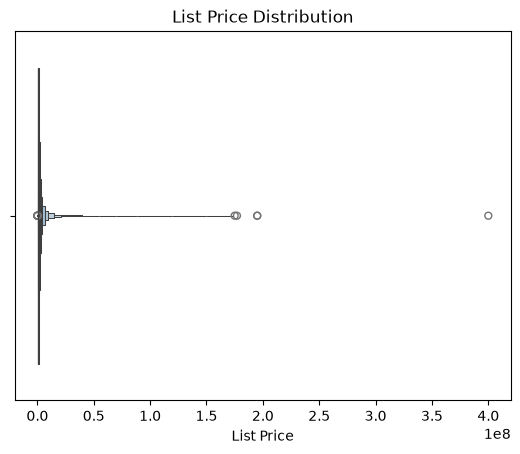

In [27]:
# boxplot for list price distribution
sns.boxenplot(x=df_list["ListPrice"])
plt.title("List Price Distribution")
plt.xlabel("List Price")
plt.show()

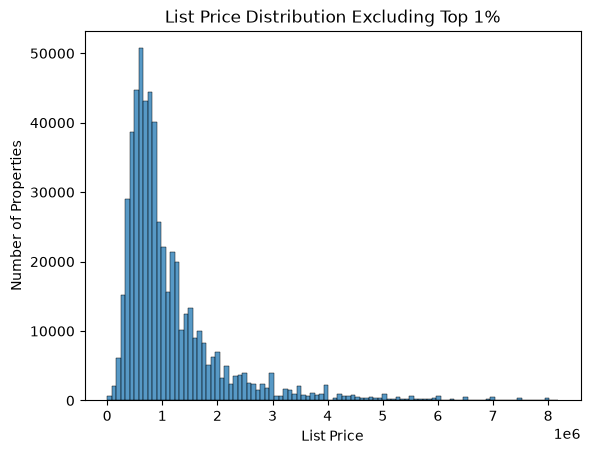

In [28]:
upper_limit = df_list["ListPrice"].quantile(0.99)

sns.histplot(df_list[df_list["ListPrice"] <= upper_limit]["ListPrice"], bins=100)
plt.title("List Price Distribution Excluding Top 1%")
plt.xlabel("List Price")
plt.ylabel("Number of Properties")
plt.show()

In [29]:
df_list[df_list["OriginalListPrice"]<0]

df_list["OriginalListPrice"].describe()

count    5.704110e+05
mean     1.401146e+06
std      7.376630e+06
min      0.000000e+00
25%      5.855000e+05
50%      8.490000e+05
75%      1.395000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

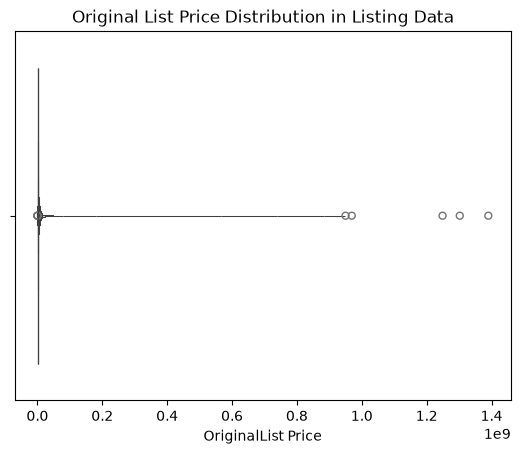

In [30]:
# boxplot for original list price distribution
sns.boxenplot(x=df_list["OriginalListPrice"])
plt.title("Original List Price Distribution in Listing Data")
plt.xlabel("OriginalList Price")
plt.show()

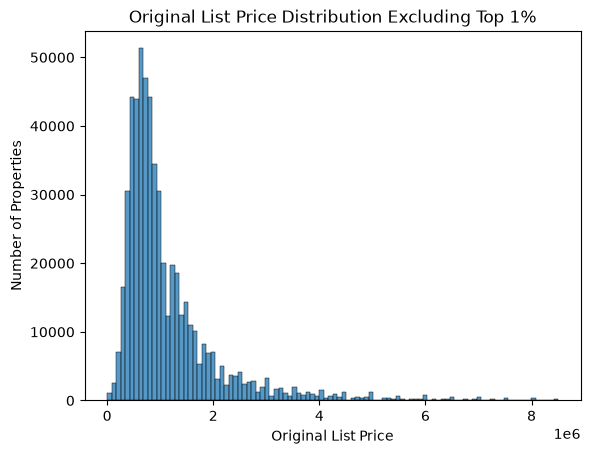

In [31]:
upper_limit = df_list["OriginalListPrice"].quantile(0.99)

sns.histplot(df_list[df_list["OriginalListPrice"] <= upper_limit]["OriginalListPrice"], bins=100)
plt.title("Original List Price Distribution Excluding Top 1%")
plt.xlabel("Original List Price")
plt.ylabel("Number of Properties")
plt.show()

In [37]:
df_list = df_list.dropna(subset=["LivingArea"])

df_list.shape

(570657, 48)

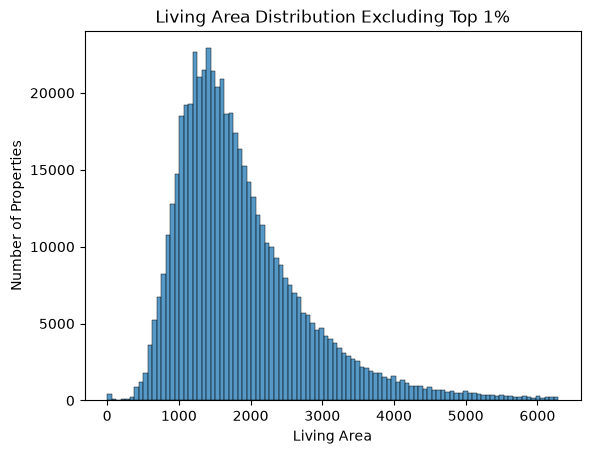

In [38]:
upper_limit = df_list["LivingArea"].quantile(0.99)

sns.histplot(df_list[df_list["LivingArea"] <= upper_limit]["LivingArea"], bins=100)
plt.title("Living Area Distribution Excluding Top 1%")
plt.xlabel("Living Area")
plt.ylabel("Number of Properties")
plt.show()

In [39]:
df_list["LotSizeAcres"].describe()

count    5.238860e+05
mean     6.267013e+01
std      1.180629e+04
min      0.000000e+00
25%      1.200000e-01
50%      1.700000e-01
75%      3.136000e-01
max      4.187292e+06
Name: LotSizeAcres, dtype: float64

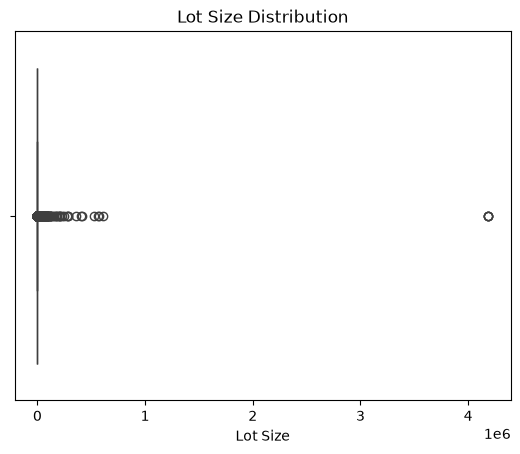

In [40]:
sns.boxplot(x=df_list["LotSizeAcres"])
plt.title("Lot Size Distribution")
plt.xlabel("Lot Size")
plt.show()

In [41]:
upper_limit = df_list["LotSizeAcres"].quantile(0.99)


print(df_list[df_list["LotSizeAcres"]>=upper_limit].shape)
print(df_list[df_list["LotSizeAcres"]>=upper_limit]["LotSizeAcres"].sort_values(ascending=False))
df_list[df_list["LotSizeAcres"]>=upper_limit].head()

(5252, 48)
170943    4.187292e+06
170699    4.187292e+06
215428    4.187292e+06
293827    4.187292e+06
107393    6.048240e+05
              ...     
437938    1.352010e+01
106351    1.352010e+01
375285    1.352010e+01
512035    1.352010e+01
377514    1.352010e+01
Name: LotSizeAcres, Length: 5252, dtype: float64


,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,StateOrProvince,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode
81,2995000.0,1066176521,NaN,NaN,Anthony,Ford,38.749084,-122.587673,17320 Butts Canyon Road,Residential,...,CA,NaN,True,1.0,NaN,One,False,2.0,Lake,95461
133,2145000.0,1064878707,NaN,NaN,Sam,Mudd,39.993321,-122.093918,6725 State Highway 99e,Residential,...,CA,NaN,True,2.0,NaN,Two,False,3.0,Los Molinos Unified,96055
184,1100000.0,1063452315,NaN,NaN,Rip,Fritzer,32.707116,-116.799113,2851 Harper Ranch Road,Residential,...,CA,NaN,True,1.0,NaN,One,False,0.0,Grossmont Union,91935
242,425000.0,1062155326,NaN,NaN,Zoe,Alexander,37.554163,-120.002405,6164 Sherlock Road,Residential,...,CA,NaN,True,1.0,NaN,One,False,0.0,Mariposa County Unified,95345
308,1320000.0,1061988785,2024-02-28,1280000.0,Mike,Naylor,33.724968,-118.318463,2501 Bowfin Avenue,Residential,...,CA,NaN,True,1.0,NaN,One,False,2.0,Los Angeles Unified,90732


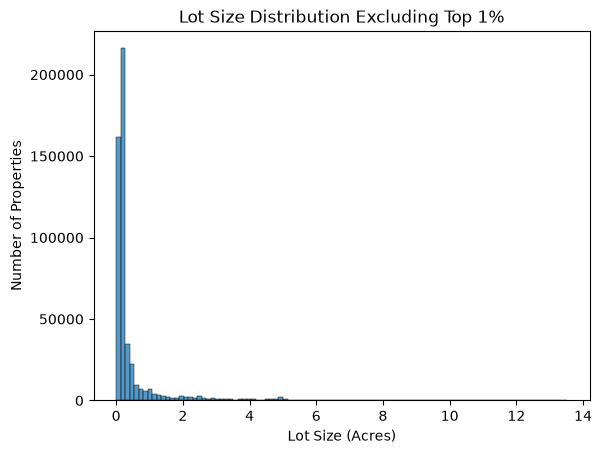

In [42]:
sns.histplot(df_list[df_list["LotSizeAcres"] <= upper_limit]["LotSizeAcres"], bins=100)
plt.title("Lot Size Distribution Excluding Top 1%")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Number of Properties")
plt.show()

In [43]:
df_list["BedroomsTotal"].describe()

count    570535.000000
mean          3.226447
std           1.185080
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          94.000000
Name: BedroomsTotal, dtype: float64

In [44]:
df_list["BedroomsTotal"].value_counts(normalize=True).sort_values(ascending=False)

BedroomsTotal
3.0     0.377067
4.0     0.259919
2.0     0.207551
5.0     0.085285
1.0     0.040048
6.0     0.018285
7.0     0.004824
0.0     0.003860
8.0     0.001688
9.0     0.000626
10.0    0.000356
11.0    0.000144
12.0    0.000107
13.0    0.000044
14.0    0.000033
15.0    0.000032
16.0    0.000032
18.0    0.000014
17.0    0.000012
20.0    0.000011
26.0    0.000009
34.0    0.000007
45.0    0.000007
23.0    0.000005
21.0    0.000004
32.0    0.000004
24.0    0.000004
37.0    0.000004
19.0    0.000004
94.0    0.000002
33.0    0.000002
72.0    0.000002
40.0    0.000002
25.0    0.000002
31.0    0.000002
71.0    0.000002
36.0    0.000002
22.0    0.000002
57.0    0.000002
39.0    0.000002
Name: proportion, dtype: float64

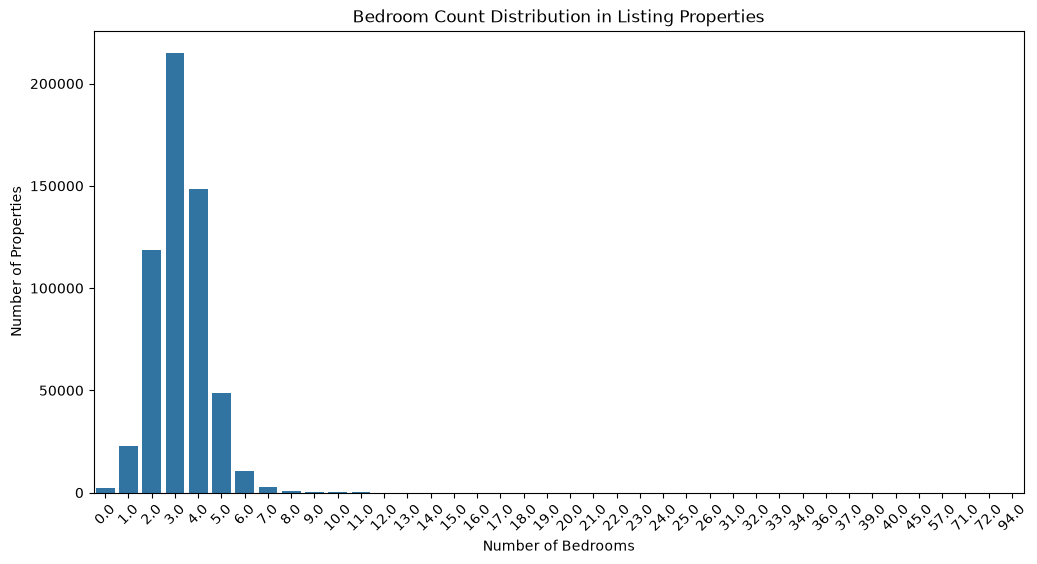

In [48]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BedroomsTotal", data = df_list)
plt.title("Bedroom Count Distribution in Listing Properties")
plt.xticks(rotation = 45)
plt.xlabel('Number of Bedrooms')
plt.ylabel("Number of Properties")
plt.show()

In [49]:
df_list['BathroomsTotalInteger'].describe()

count    570621.000000
mean          2.626524
std           3.180666
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max        2208.000000
Name: BathroomsTotalInteger, dtype: float64

In [50]:
df_list["BathroomsTotalInteger"].value_counts(normalize=True).sort_values(ascending=False)

BathroomsTotalInteger
2.0       0.412728
3.0       0.325151
1.0       0.113986
4.0       0.085269
5.0       0.034115
6.0       0.014814
7.0       0.006153
8.0       0.002930
9.0       0.001589
0.0       0.001158
10.0      0.000766
11.0      0.000471
12.0      0.000275
13.0      0.000179
14.0      0.000133
15.0      0.000067
16.0      0.000047
20.0      0.000026
17.0      0.000025
22.0      0.000016
21.0      0.000014
18.0      0.000014
25.0      0.000014
32.0      0.000009
26.0      0.000007
19.0      0.000007
45.0      0.000005
27.0      0.000004
24.0      0.000004
23.0      0.000004
46.0      0.000004
48.0      0.000002
153.0     0.000002
33.0      0.000002
2208.0    0.000002
67.0      0.000002
35.0      0.000002
31.0      0.000002
36.0      0.000002
40.0      0.000002
59.0      0.000002
Name: proportion, dtype: float64

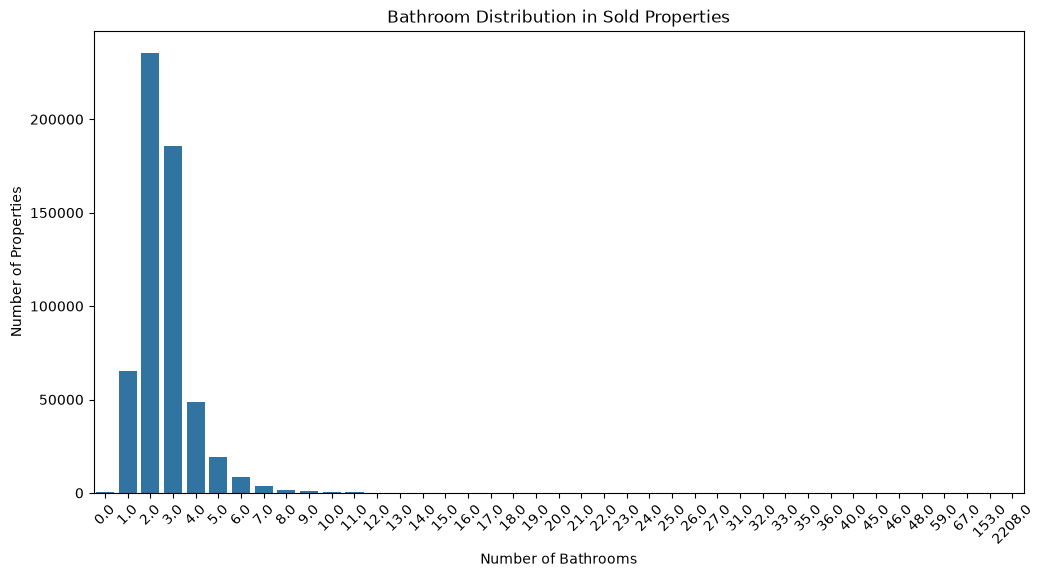

In [51]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BathroomsTotalInteger", data = df_list)
plt.xticks(rotation=45)
plt.title('Bathroom Distribution in Sold Properties')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Properties')
plt.show()

In [53]:
df_list["DaysOnMarket"].describe()

count    570657.000000
mean         18.651074
std          26.170858
min         -58.000000
25%           5.000000
50%          10.000000
75%          21.000000
max        1063.000000
Name: DaysOnMarket, dtype: float64

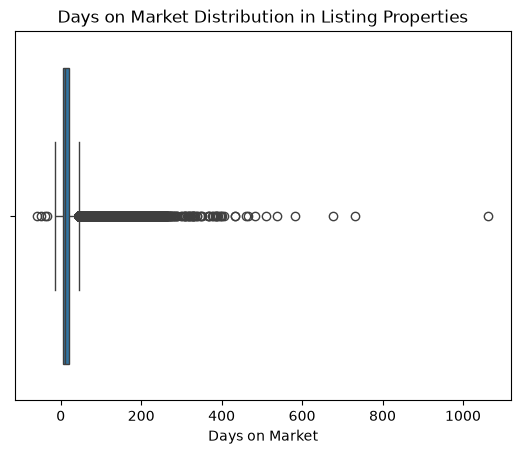

In [54]:
sns.boxplot(x=df_list["DaysOnMarket"])
plt.title("Days on Market Distribution in Listing Properties")
plt.xlabel("Days on Market")
plt.show()

In [55]:
neg_days_market = df_list[df_list["DaysOnMarket"]<0]

print(neg_days_market.shape)
neg_days_market["DaysOnMarket"]

(28, 48)


162      -48
166      -58
873       -1
2725     -33
12371     -3
13769     -2
13926     -1
15325     -5
17793    -13
23098     -2
26067    -10
30184     -2
31872     -6
37544     -2
44123    -14
48250    -12
95883     -6
236068    -1
275227    -3
285108    -6
351153    -1
390541    -4
400696    -7
431182    -2
452981   -39
461610   -14
464318    -2
562708    -1
Name: DaysOnMarket, dtype: int64

In [56]:
upper_limit  = df_list["DaysOnMarket"].quantile(0.99)

print(df_list[df_list["DaysOnMarket"]>=upper_limit].shape)
print(df_list[df_list["DaysOnMarket"]>=upper_limit]["DaysOnMarket"].sort_values(ascending=False))
df_list[df_list["DaysOnMarket"]>=upper_limit].head()

(5821, 48)
564783    1063
415758     731
12941      677
178180     583
411128     537
          ... 
405332     136
424518     136
414704     136
481549     136
153804     136
Name: DaysOnMarket, Length: 5821, dtype: int64


,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,StateOrProvince,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode
1394,10700000.0,1059828335,NaN,NaN,Ashley,Czuk,NaN,NaN,100 The Strand,Residential,...,CA,NaN,True,NaN,NaN,NaN,False,2.0,Other,90254
2957,1325000.0,1059500858,2024-03-05,1630435.0,Talin,Amirian,34.169501,-118.060226,435 N Lima Street,Residential,...,CA,NaN,True,2.0,NaN,Two,False,NaN,NaN,91024
2970,5990000.0,1059499983,NaN,NaN,NaN,Axis Investment,NaN,NaN,883 Rorke Way,Residential,...,CA,NaN,True,NaN,NaN,NaN,False,2.0,Palo Alto Unified,94303
4568,7498000.0,1059321297,NaN,NaN,Sean,Foley,NaN,NaN,240 Laning Drive,Residential,...,CA,NaN,True,NaN,Woodside,NaN,False,3.0,Other,94062
4711,644000.0,1059104935,NaN,NaN,Veronica,Pruneda,NaN,NaN,3137 Seacrest Avenue 18,Residential,...,CA,NaN,False,NaN,NaN,NaN,False,2.0,Other,93933


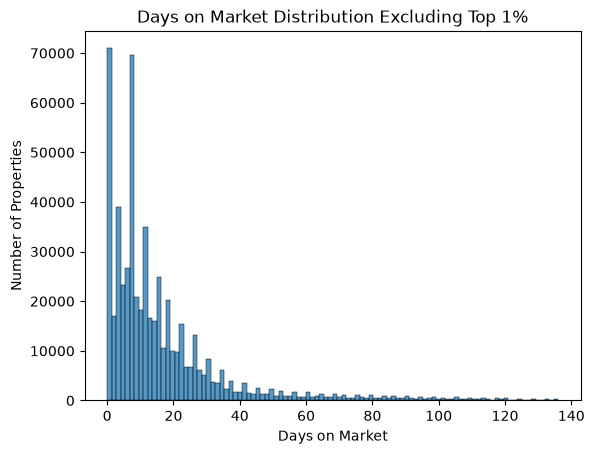

In [57]:
df_list = df_list[df_list["DaysOnMarket"]>= 0]

sns.histplot(df_list[df_list["DaysOnMarket"] <= upper_limit]["DaysOnMarket"], bins=100)
plt.title("Days on Market Distribution Excluding Top 1%")
plt.xlabel("Days on Market")
plt.ylabel("Number of Properties")
plt.show()

In [58]:
def dom_split(days):
    if days <=30:
        return "fast sale"
    
    elif days>30 and days <=90:
        return "moderate sale"
    
    elif days >90 and days<=180:
        return "slow sale"
    
    elif days > 180:
        return "long time sale"

df_list["DOM_category"] = df_list["DaysOnMarket"].apply(dom_split)

df_list["DOM_category"].value_counts(normalize=True).sort_values(ascending=False)

DOM_category
fast sale         0.852317
moderate sale     0.117250
slow sale         0.027026
long time sale    0.003407
Name: proportion, dtype: float64

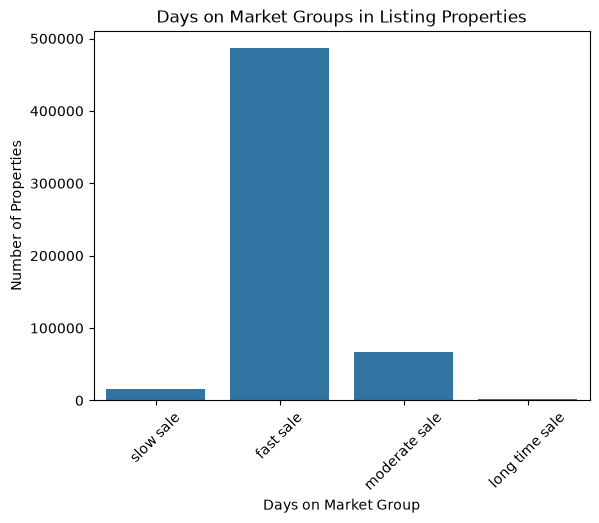

In [63]:
sns.countplot(x="DOM_category",data= df_list)

plt.title("Days on Market Groups in Listing Properties")
plt.xlabel("Days on Market Group")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

In [60]:
df_list["YearBuilt"].describe()

count    569780.000000
mean       1979.630566
std          26.992705
min        1776.000000
25%        1961.000000
50%        1980.000000
75%        2001.000000
max        2028.000000
Name: YearBuilt, dtype: float64

In [61]:
df_list["PropertyAge"] = 2026 - df_list["YearBuilt"]

df_list["PropertyAge"].value_counts(normalize=True).sort_values(ascending=False)

PropertyAge
2.0      0.023242
37.0     0.020448
47.0     0.018890
46.0     0.018688
1.0      0.018665
           ...   
250.0    0.000002
172.0    0.000002
171.0    0.000002
153.0    0.000002
234.0    0.000002
Name: proportion, Length: 175, dtype: float64

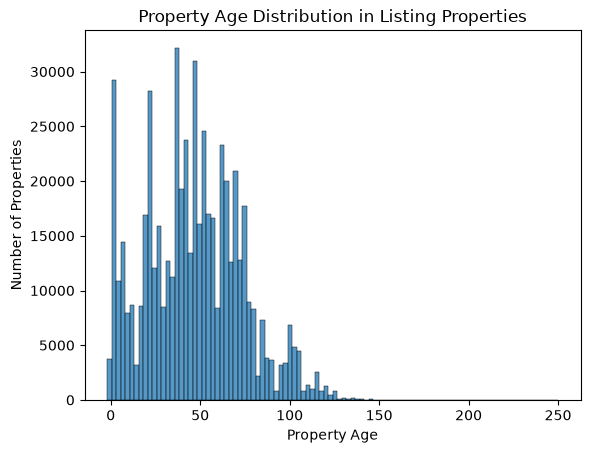

In [62]:
sns.histplot(df_list["PropertyAge"], bins=100)

plt.title("Property Age Distribution in Listing Properties")
plt.xlabel("Property Age")
plt.ylabel("Number of Properties")
plt.show()

In [64]:
def age_split(ages):
    if ages<=5:
        return "0-5"
    
    elif ages > 5 and ages<=10:
        return "6-10"
    
    elif ages>10 and ages <=20:
        return "11-20"
    
    elif ages>20 and ages<=40:
        return "21-40"
    
    elif ages>40 and ages<=70:
        return "41-70"
    
    elif ages>70:
        return "70+"

df_list["PropertyAgeGroup"] = df_list["PropertyAge"].apply(age_split)

df_list["PropertyAgeGroup"].value_counts(normalize=True)

PropertyAgeGroup
41-70    0.385219
21-40    0.245900
70+      0.186970
0-5      0.076963
11-20    0.065536
6-10     0.039412
Name: proportion, dtype: float64

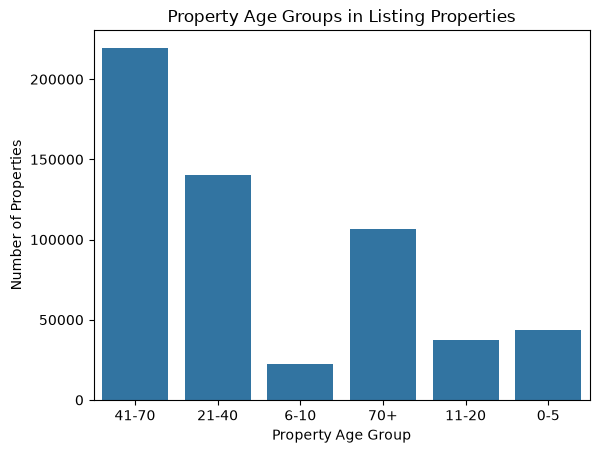

In [66]:
sns.countplot(x="PropertyAgeGroup", data = df_list)

plt.title("Property Age Groups in Listing Properties")
plt.xlabel("Property Age Group")
plt.ylabel("Number of Properties")
plt.show()

In [67]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [68]:
mortgage.columns = ['date', 'rate_30yr_fixed']

mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage.head()

,date,rate_30yr_fixed,year_month
0,1971-04-02,7.33,1971-04
1,1971-04-09,7.31,1971-04
2,1971-04-16,7.31,1971-04
3,1971-04-23,7.31,1971-04
4,1971-04-30,7.29,1971-04


In [69]:
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [70]:
df_list['year_month'] = pd.to_datetime(df_list['ListingContractDate']).dt.to_period('M')

df_list = df_list.merge(mortgage_monthly, on='year_month', how='left')

df_list["rate_30yr_fixed"].head()

0    6.6425
1    6.6425
2    6.6425
3    6.6425
4    6.6425
Name: rate_30yr_fixed, dtype: float64

In [71]:
df_list['rate_30yr_fixed'].isnull().sum()

np.int64(0)